In [48]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import norm
import ast
import matplotlib.pyplot as plt
import forestplot as fp
from scipy import stats

In [49]:
ancestry = pd.read_csv('/home/jupyter/workspace/vwb-aou-datasets-controlled/v8/wgs/short_read/snpindel/aux/ancestry/echo_v4_r2.ancestry_preds.tsv', sep='\t')
ancestry['pca_features'] = ancestry['pca_features'].apply(ast.literal_eval)
pca_df = pd.DataFrame(ancestry['pca_features'].tolist(), index=ancestry.index)
pca_df.columns = [f'PC{i+1}' for i in range(16)]
ancestry = pd.concat([ancestry.drop(columns=['pca_features']), pca_df], axis=1)
ancestry = ancestry[ancestry['ancestry_pred'] == ancestry['ancestry_pred_other']]
deprivation = pd.read_csv('../deprivation_index.tsv', sep='\t')

In [50]:
populations = ancestry.ancestry_pred.unique().tolist()
relatedness = pd.read_csv('~/workspace/vwb-aou-datasets-controlled/v8/wgs/short_read/snpindel/aux/relatedness/samples_relatedness_flagged_samples.tsv', sep='\t')
t = 'eGFR'

In [51]:
def simplify_egfr_label(label):
    """
    Maps complex clinical eGFR concepts to concise, descriptive labels.
    """
    mapping = {
        'Glomerular filtration rate/1.73 sq M.predicted [Volume Rate/Area] in Serum, Plasma or Blood by Creatinine-based formula (MDRD)': 'eGFR (MDRD)',
        'Glomerular filtration rate/1.73 sq M.predicted among blacks [Volume Rate/Area] in Serum, Plasma or Blood by Creatinine-based formula (MDRD)': 'eGFR (MDRD, Black)',
        'Glomerular filtration rate/1.73 sq M.predicted among non-blacks [Volume Rate/Area] in Serum, Plasma or Blood by Creatinine-based formula (MDRD)': 'eGFR (MDRD, Non-Black)',
        'Glomerular filtration rate/1.73 sq M.predicted [Volume Rate/Area] in Serum, Plasma or Blood by Creatinine-based formula (CKD-EPI)': 'eGFR (CKD-EPI)',
        'Glomerular filtration rate/1.73 sq M.predicted among blacks [Volume Rate/Area] in Serum, Plasma or Blood by Creatinine-based formula (CKD-EPI)': 'eGFR (CKD-EPI, Black)',
        'Glomerular filtration rate/1.73 sq M.predicted among non-blacks [Volume Rate/Area] in Serum, Plasma or Blood by Creatinine-based formula (CKD-EPI)': 'eGFR (CKD-EPI, Non-Black)',
        'Glomerular filtration rate/1.73 sq M.predicted [Volume Rate/Area] in Serum, Plasma or Blood by Creatinine-based formula (CKD-EPI 2021)': 'eGFR (CKD-EPI 2021)',
        'Glomerular filtration rate/1.73 sq M.predicted [Volume Rate/Area] in Serum, Plasma or Blood': 'eGFR (General)',
        'Creatinine and Glomerular filtration rate.predicted panel - Serum, Plasma or Blood': 'eGFR (Panel)'
    }
    
    return mapping.get(label, "Unknown")

# Example usage with your dataframe:
# df['simplified_label'] = df['standard_concept_name'].apply(simplify_egfr_label)

In [52]:
trait_simplifiers = {
    'eGFR': simplify_egfr_label,
}

In [53]:
covariates = ['age_at_measurement', 'sex', 'deprivation_index', 'age_age', 'age_sex'] + [f'PC{i+1}' for i in range(16)]

    # 1. File loading (Consider changing to pd.read_parquet() for massive speedups!)
pgs = pd.read_csv(f'../score/{t}/genome_wide_pgs.tsv', sep='\t')
pheno = pd.read_csv(f'../Phenotype/{t}_new.tsv', sep='\t')
pheno = pheno[~pheno['id'].isin(relatedness['sample_id'])]
pheno['short_name'] = pheno["standard_concept_name"].apply(trait_simplifiers[t])

df = pgs.merge(pheno, left_on='#IID', right_on='id', how='inner')
df = df.merge(ancestry, left_on='#IID', right_on='research_id', how='inner')
df = df.merge(deprivation[['person_id', 'deprivation_index']], left_on='#IID', right_on='person_id', how='inner')

        # 3. Vectorize feature engineering
df['age_age'] = df['age_at_measurement'] ** 2 # slightly cleaner than multiplication
df['sex'] = df['sex_at_birth'].map({'Female': 0, 'Male': 1}).astype(float)
df['age_sex'] = df['age_at_measurement'] * df['sex']

cols_to_keep = ['#IID', 'ancestry_pred', 'ancestry_pred_other', 'phenotype', 'BETA_SUM', 'short_name'] + covariates
df_clean = df[cols_to_keep].dropna()
    
df_clean = df_clean[df_clean['ancestry_pred'] == 'afr']

if t == 'eGFR':
    df_clean = df_clean[~df_clean['short_name'].str.contains('Non-Black', na=False)]

In [54]:
def prioritize_eGFR_measurements(df_clean, include_red_quality=False):
  """Prioritizes and selects a single preferred eGFR measurement per individual

  based on exact blue vs. red circle tiers from the UpSet plot.
  """
  # True Blue Circle categories (high quality / consensus formulas)
  blue_categories = ['eGFR (CKD-EPI, Black)', 'eGFR (CKD-EPI 2021)', 'eGFR (CKD-EPI)']

  # Red Circle categories (Panel, General, and MDRD variants)
  red_categories = [
      'eGFR (Panel)',
      'eGFR (General)',
      'eGFR (MDRD)',
      'eGFR (MDRD, Black)',
  ]

  # Filter based on whether red quality is allowed
  if include_red_quality:
    allowed_categories = blue_categories + red_categories
  else:
    allowed_categories = blue_categories

  df_filtered = df_clean[df_clean['short_name'].isin(allowed_categories)].copy()

  # Your exact priority hierarchy:
  # 1. CKD-EPI, Black (Blue)
  # 2. CKD-EPI 2021 (Blue)
  # 3. CKD-EPI (Blue)
  # 4 & 5. Panel / General (Red - takes precedence over MDRDs)
  # 6. MDRD (Red)
  # 7. MDRD, Black (Red)
  priority_order = {
      'eGFR (CKD-EPI, Black)': 1,
      'eGFR (CKD-EPI 2021)': 2,
      'eGFR (CKD-EPI)': 3,
      'eGFR (Panel)': 4,
      'eGFR (General)': 5,
      'eGFR (MDRD)': 6,
      'eGFR (MDRD, Black)': 7,
  }

  df_filtered['priority'] = df_filtered['short_name'].map(priority_order)

  # Sort and drop duplicates to keep the highest priority measurement per individual
  df_sorted = df_filtered.sort_values(by=['#IID', 'priority'])
  df_prioritized = df_sorted.drop_duplicates(subset=['#IID'], keep='first')

  return df_prioritized

In [55]:
df_clean = df_clean[df_clean['phenotype'] < 1000]

In [56]:
df_blue_only = prioritize_eGFR_measurements(df_clean, include_red_quality=False)
df_blue_and_red = prioritize_eGFR_measurements(df_clean, include_red_quality=True)

In [57]:
def ci_rsq(rsq, n, k, level=0.95):
    """
    Replicates the exact math from psychometric::CI.Rsq in R.
    Computes the confidence interval for R-squared using the Olkin & Finn approximation.
    """
    # Calculate Standard Error of R-squared
    sersq = np.sqrt((4 * rsq * (1 - rsq)**2 * (n - k - 1)**2) / ((n**2 - 1) * (n + 3)))
    
    # Calculate Z-score for the given confidence level (e.g., 1.96 for 95%)
    z = norm.ppf((1 + level) / 2)
    
    lcl = rsq - z * sersq
    ucl = rsq + z * sersq
    
    return lcl, ucl

def eval_R2_CI(data, response, pgs_term=None, covariates=None, level=0.95):
    if covariates is None:
        covariates = []
        
    all_predictors = covariates.copy()
    if pgs_term is not None:
        all_predictors = [pgs_term] + all_predictors
        
    if len(all_predictors) == 0:
        raise ValueError("You must provide at least a pgs_term or covariates.")
        
    X = data[all_predictors]
    X = sm.add_constant(X)
    y = data[response]
    
    model = sm.OLS(y, X)
    results = model.fit()
    
    # --- NEW: Extract Beta and SE along with the p-value ---
    if pgs_term is not None:
        p_val = results.pvalues[pgs_term]
        beta = results.params[pgs_term]
        se = results.bse[pgs_term]
    else:
        p_val = results.pvalues[covariates].min()
        beta = np.nan # Covariate-only models don't have a PGS beta
        se = np.nan
        
    rsq = results.rsquared
    n = len(data)
    k = len(all_predictors)
    lcl, ucl = ci_rsq(rsq, n, k, level) 
    
    res_df = pd.DataFrame([{
        'response': response,
        'pgs_term': pgs_term if pgs_term else "None",
        'covariates': "+".join(covariates) if covariates else "None",
        'metric': 'R2',
        'eval': rsq,
        'l_eval': lcl,
        'u_eval': ucl,
        'P_pgs': p_val,
        'beta': beta,  # Added to output
        'se': se,      # Added to output
        'n': n
    }])
    
    return res_df

# (No changes needed to eval_CI wrapper!)
def eval_CI(data, response, pgs_term=None, covariates=None, family="gaussian", level=0.95):
    """
    Main wrapper function to evaluate predictive performance, 
    isolating the p-value of the primary PGS term.
    """
    if covariates is None:
        covariates = []
        
    if family not in ["gaussian", "binomial"]:
        raise ValueError("Family must be 'gaussian' or 'binomial'")
        
    if family == "gaussian":
        # Pass the separated terms down to the R2 function
        return eval_R2_CI(data, response, pgs_term, covariates, level)
    else:
        # When you build your AUROC function, it will now safely 
        # receive the separated pgs_term and covariates as well!
        # return eval_AUROC_CI(data, response, pgs_term, covariates, level)
        pass

In [58]:
def run_ivw_with_q(betas, ses, ns=None):
    betas = np.array(betas, dtype=float)
    ses = np.array(ses, dtype=float)

    valid_mask = (ses > 0) & np.isfinite(ses) & np.isfinite(betas)

    if ns is not None:
        ns = np.array(ns, dtype=float)
        valid_mask = valid_mask & np.isfinite(ns)
        # Filter ns using the same mask BEFORE subsetting betas/ses
        ns_filtered = ns[valid_mask]
    else:
        ns_filtered = None

    betas = betas[valid_mask]
    ses = ses[valid_mask]

    k = len(betas)
    if k == 0:
        return {
            "eval": np.nan,
            "l_eval": np.nan,
            "u_eval": np.nan,
            "q": np.nan,
            "q_df": 0,
            "q_pval": np.nan,
            "n": np.nan,
            "k": 0
        }

    weights = 1.0 / (ses ** 2)

    meta_beta = np.sum(weights * betas) / np.sum(weights)
    meta_se = np.sqrt(1.0 / np.sum(weights))

    # Calculate Cochran's Q statistic
    q_stat = np.sum(weights * (betas - meta_beta) ** 2)
    q_df = k - 1
    
    # Calculate p-value from Chi-squared distribution (handle df=0 edge case)
    if q_df > 0:
        q_pval = 1.0 - stats.chi2.cdf(q_stat, df=q_df)
    else:
        q_pval = 1.0

    return {
        "eval": meta_beta,
        "l_eval": meta_beta - 1.96 * meta_se,
        "u_eval": meta_beta + 1.96 * meta_se,
        "q": q_stat,
        "q_df": q_df,
        "q_pval": q_pval,
        "n": np.sum(ns_filtered) if ns_filtered is not None else np.nan,
        "k": k
    }

In [59]:
r2_dfs = []
for m in df_blue_only['short_name'].unique().tolist():
    subset = df_blue_only[df_blue_only['short_name'] == m]
    if len(subset) <= 3:
        print(m)
    if len(subset) > 3:
        pgs_only = eval_CI(subset, 'phenotype', 'BETA_SUM')
        pgs_only['trait'] = 'eGFR (Core)'
        pgs_only['short_name'] = m
        r2_dfs.append(pgs_only)

In [60]:
for m in df_blue_and_red['short_name'].unique().tolist():
    subset = df_blue_and_red[df_blue_and_red['short_name'] == m]
    if len(subset) <= 3:
        print(m)
    if len(subset) > 3:
        pgs_only = eval_CI(subset, 'phenotype', 'BETA_SUM')
        pgs_only['trait'] = 'eGFR (Comprehensive)'
        pgs_only['short_name'] = m
        r2_dfs.append(pgs_only)

In [61]:
forest_input = pd.concat(r2_dfs)

In [63]:
forest_input['cohort'] = 'All of Us (PRISM)'

In [66]:
forest_input[['eval', 'l_eval', 'u_eval', 'n', 'short_name']].drop_duplicates()

,eval,l_eval,u_eval,n,short_name
0,0.001673,-0.003151,0.006496,1094,eGFR (CKD-EPI)
0,0.009793,0.000658,0.018928,1761,"eGFR (CKD-EPI, Black)"
0,0.000453,-0.001800,0.002707,1363,eGFR (CKD-EPI 2021)
0,0.000646,-0.001761,0.003054,1704,eGFR (MDRD)
0,0.000494,-0.002295,0.003284,968,eGFR (Panel)
0,0.000387,-0.001469,0.002242,1717,eGFR (General)
0,0.001122,-0.001792,0.004037,2019,"eGFR (MDRD, Black)"


In [68]:
trait_meta.to_csv('ivw_egfr_prism.tsv', sep='\t', index=False)

In [20]:
results = []

for t in ['eGFR (Core)', 'eGFR (Comprehensive)']:
    subset = forest_input[forest_input["trait"] == t].copy()
    subset['sd'] = (subset['eval'] - subset['l_eval']) / 1.96

    result = run_ivw_with_q(
        betas=subset["eval"],
        ses=subset["sd"],
        ns=subset["n"]
    )

    result["trait"] = t
    #result["trait (study)"] = f"{t} (IVW meta)"
    results.append(result)

trait_meta = pd.DataFrame(results)

In [21]:
trait_meta['short_name'] = trait_meta['trait']
trait_meta['cohort'] = 'All of Us (meta-analysis)'

In [22]:
input_interm = pd.concat([forest_input[['eval', 'l_eval', 'u_eval', 'n', 'trait', 'cohort', 'short_name']], trait_meta[['eval', 'l_eval', 'u_eval', 'n', 'trait','cohort','short_name']]])

In [25]:
ivw_baseline = pd.read_csv('ivw_egfr_baseline.tsv', sep='\t')
#ivw_baseline = ivw_baseline[ivw_baseline['model'] == 'baseline']
ivw_baseline = ivw_baseline[['eval', 'l_eval', 'u_eval', 'n', 'trait']]
ivw_baseline['cohort'] = 'All of Us (meta-analysis)'
ivw_baseline['short_name'] = ivw_baseline.trait.apply(lambda x : x + ' (baseline)')

In [26]:
input_interm = pd.concat([input_interm, ivw_baseline])

In [27]:
trait_tissue_dict = dict(zip(['INI30120', 'INI50030700', 'INI1003063', 'INI20030780'], ['BLOOD', 'KIDNEY', 'LUNG', 'LIVER']))

ukb = pd.read_csv('../UKB_performance.tsv', sep='\t', skiprows=3)
ukb = ukb[(ukb['model'] == 'PGS') & (ukb['population'] == 'Afr') & (ukb['Source Cohort for Fine-mapped Variants'] == 'MVP_AFR')]
ukb = ukb[ukb.apply(lambda x: x['Tissue'] == trait_tissue_dict[x['Phenotype']], axis=1)]
ukb['trait'] = ['Lymphocyte_count', 'LDL_C', 'FEV1_FVC', 'eGFR']
ukb.columns = ['Phenotype', 'eval', 'l_eval', 'u_eval', 'P_pgs', 'n', 'population', 'model', 'Tissue', 'Source cohort', 'trait']
ukb['cohort'] = 'uk biobank'
ukb['short_name'] = ['Lymphocyte_count', 'LDL_C', 'FEV1_FVC', 'eGFR']

In [28]:
input_df = pd.concat((ukb[['eval', 'l_eval', 'u_eval', 'n', 'trait', 'cohort', 'short_name']], input_interm[['eval', 'l_eval', 'u_eval', 'n', 'trait', 'cohort', 'short_name']]))

In [29]:
trait_colors = {
   "Lymphocyte_count" :"#e09898",
    "FEV1_FVC": "#bed78e",
    "eGFR": "#b1cde1",
    "LDL_C": "#edbe73"
}

input_df["color"] = input_df["trait"].map(trait_colors).fillna("gray")

In [31]:
input_df["eval_fmt"] = input_df["eval"].map(lambda x: f"{x:.4f}")
input_df["l_eval_fmt"] = input_df["l_eval"].map(lambda x: f"{x:.4f}")
input_df["u_eval_fmt"] = input_df["u_eval"].map(lambda x: f"{x:.4f}")

In [32]:
input_df["r2_ci"] = input_df.apply(
    lambda row: f'{row["eval"]:.4f} [{row["l_eval"]:.4f}, {row["u_eval"]:.4f}]',
    axis=1
)

In [33]:
input_df["n_fmt"] = input_df["n"].astype(int).astype(str)

In [34]:
input_df = input_df[input_df['trait'].str.startswith('eGFR')]

In [35]:
input_df = input_df.drop(columns='trait')
input_df = input_df.drop_duplicates()

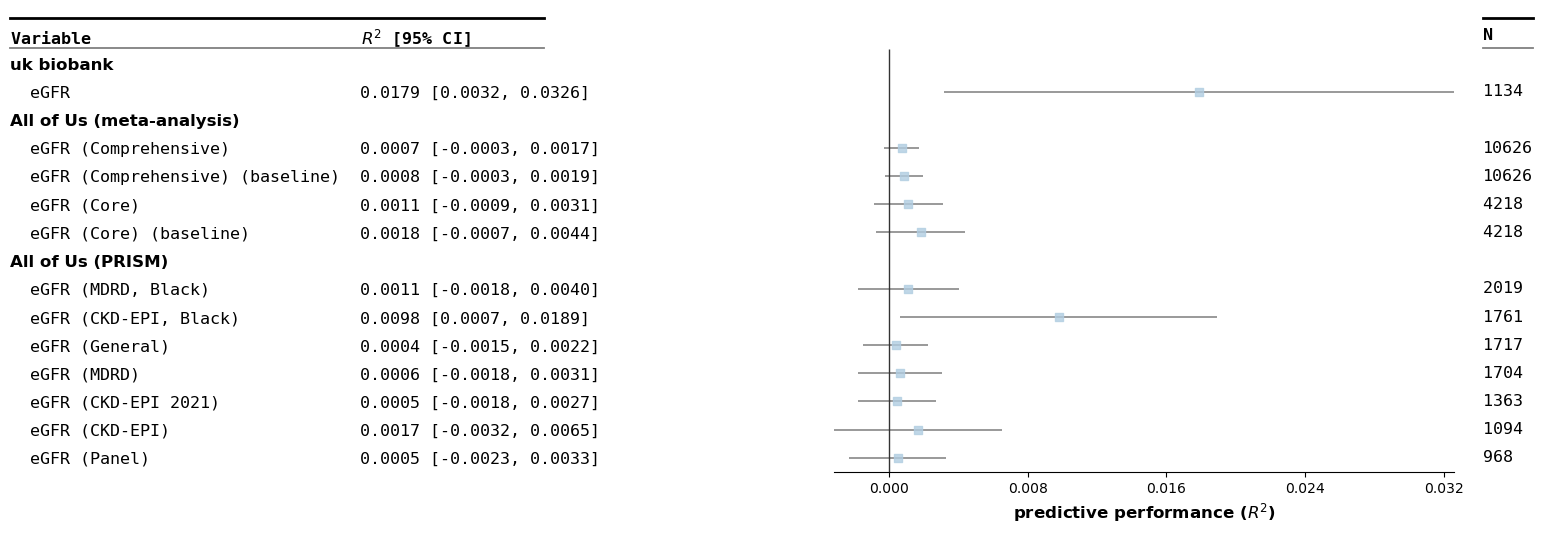

In [39]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

plot_df = input_df.copy()

cohort_order = ['uk biobank', 'All of Us (meta-analysis)', 'All of Us (PRISM)']
    
plot_df['cohort'] = pd.Categorical(plot_df['cohort'], categories=cohort_order, ordered=True)
    
plot_df = plot_df.sort_values(by=['cohort', 'n'], ascending=[True, False])

ax = fp.forestplot(
    plot_df,
    estimate="eval",
    ll="l_eval",
    hl="u_eval",
    varlabel="short_name",
    groupvar="cohort",
    annote=["r2_ci"],
    annoteheaders=[r"$R^{2}$ [95% CI]"],
    rightannote=["n_fmt"],
    right_annoteheaders=["N"],
    title="Forest Plot of Study Results",
    markercolor="#b1cde1",
    xlabel=r"predictive performance ($R^{2}$)",
    figsize=(8, 6), table=True
)
plt.savefig(f'../eGFR_new_forest_log.pdf', bbox_inches='tight')

In [40]:
aou = pd.read_csv('egfr_aou_baseline.tsv', sep='\t')
aou['cohort'] = 'All of Us (Baseline)'

In [42]:
input_df['cohort'] = ['uk biobank',
 'All of Us (PRISM)',
 'All of Us (PRISM)',
 'All of Us (PRISM)',
 'All of Us (PRISM)',
 'All of Us (PRISM)',
 'All of Us (PRISM)',
 'All of Us (PRISM)',
 'All of Us (meta-analysis)',
 'All of Us (meta-analysis)',
 'All of Us (meta-analysis)',
 'All of Us (meta-analysis)']


In [44]:
input_df = pd.concat([input_df[['eval', 'l_eval', 'u_eval', 'n', 'cohort', 'short_name']], aou[['eval', 'l_eval', 'u_eval', 'n', 'cohort', 'short_name']]])

In [45]:
input_df["eval_fmt"] = input_df["eval"].map(lambda x: f"{x:.4f}")
input_df["l_eval_fmt"] = input_df["l_eval"].map(lambda x: f"{x:.4f}")
input_df["u_eval_fmt"] = input_df["u_eval"].map(lambda x: f"{x:.4f}")
input_df["r2_ci"] = input_df.apply(
    lambda row: f'{row["eval"]:.4f} [{row["l_eval"]:.4f}, {row["u_eval"]:.4f}]',
    axis=1
)
input_df["n_fmt"] = input_df["n"].astype(int).astype(str)

In [46]:
input_df = input_df.drop_duplicates()

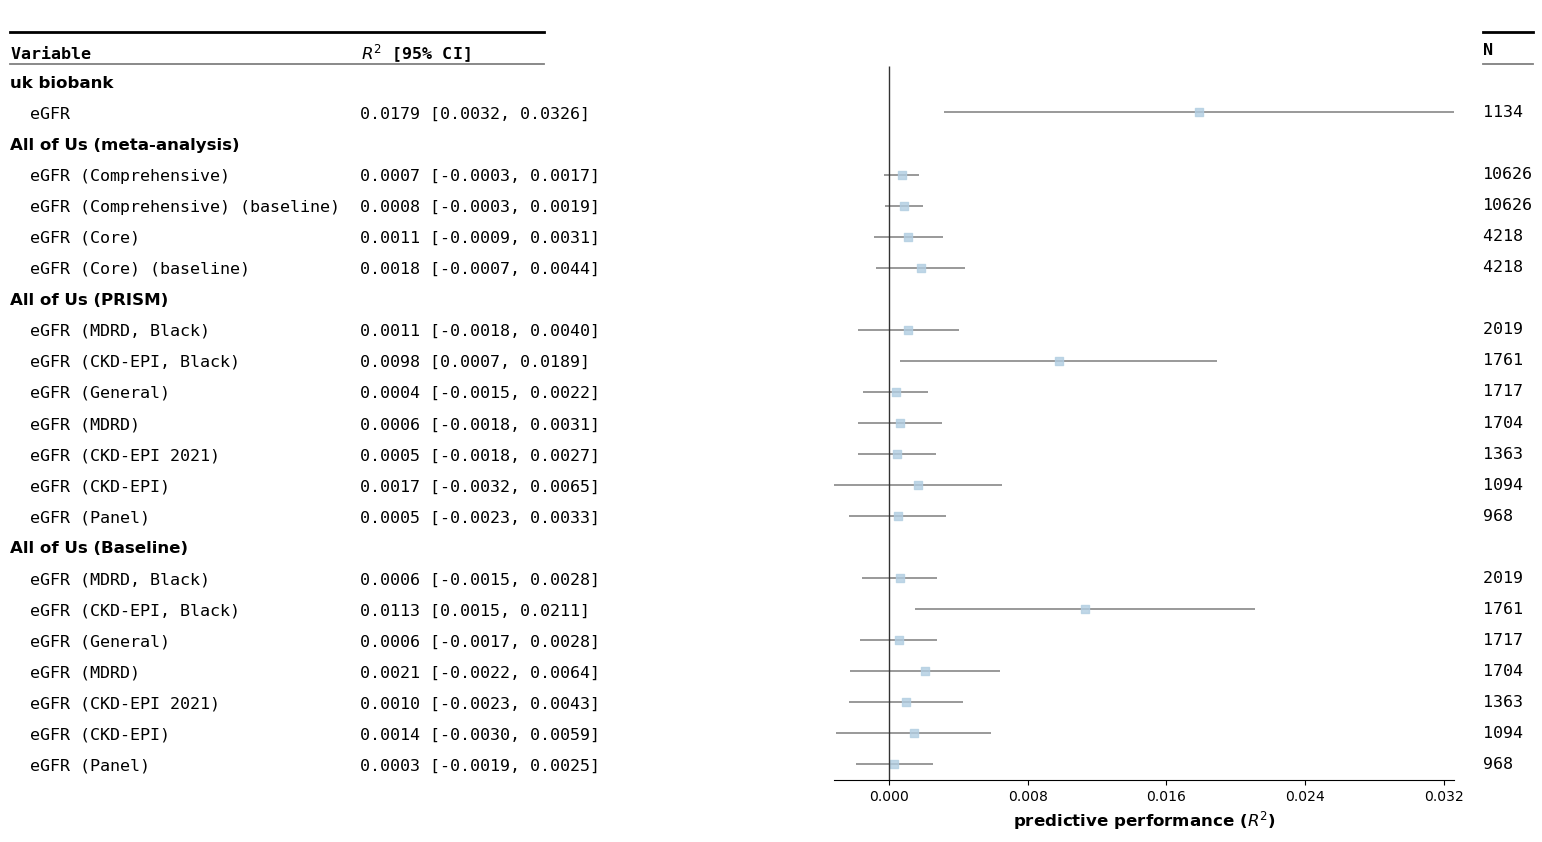

In [47]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

plot_df = input_df.copy()

cohort_order = ['uk biobank', 'All of Us (meta-analysis)', 'All of Us (PRISM)', 'All of Us (Baseline)']
    
plot_df['cohort'] = pd.Categorical(plot_df['cohort'], categories=cohort_order, ordered=True)
    
plot_df = plot_df.sort_values(by=['cohort', 'n'], ascending=[True, False])

ax = fp.forestplot(
    plot_df,
    estimate="eval",
    ll="l_eval",
    hl="u_eval",
    varlabel="short_name",
    groupvar="cohort",
    annote=["r2_ci"],
    annoteheaders=[r"$R^{2}$ [95% CI]"],
    rightannote=["n_fmt"],
    right_annoteheaders=["N"],
    title="Forest Plot of Study Results",
    markercolor="#b1cde1",
    xlabel=r"predictive performance ($R^{2}$)",
    figsize=(8, 10), table=True
)
plt.savefig(f'../full_eGFR_new_forest_log.pdf', bbox_inches='tight')